> **Chapter 15, Part 1** | Engineering lens. **Focus:** build `AssetGraph`, materialize it in dependency order, and make a cycle fail loudly.

# A Tiny Asset Graph From Scratch

An orchestrator's first job is to run things in the right order. "Right order" means: never materialize an asset before all of its upstreams are materialized. That is a topological sort of the dependency DAG, and it is the whole of this notebook.

We build three things:

1. `AssetGraph`, a container of assets.
2. `topological_order()`, which returns a safe run order or raises if the graph has a cycle.
3. `materialize()`, which runs the assets in that order and threads each asset's outputs into its downstreams.

In [1]:
from collections import deque
from dataclasses import dataclass
from typing import Callable


@dataclass
class Asset:
    name: str
    deps: list
    compute: Callable


class AssetGraph:
    def __init__(self):
        self.assets = {}

    def add(self, asset):
        self.assets[asset.name] = asset
        return self

    def _downstream(self):
        down = {n: [] for n in self.assets}
        for n, a in self.assets.items():
            for d in a.deps:
                if d in down:
                    down[d].append(n)
        return down

    def topological_order(self):
        # Kahn's algorithm. Start from assets with no upstreams, peel inward.
        indeg = {n: 0 for n in self.assets}
        for n, a in self.assets.items():
            for d in a.deps:
                if d in indeg:
                    indeg[n] += 1
        down = self._downstream()
        q = deque(sorted(n for n, k in indeg.items() if k == 0))
        order = []
        while q:
            n = q.popleft()
            order.append(n)
            for m in sorted(down[n]):
                indeg[m] -= 1
                if indeg[m] == 0:
                    q.append(m)
        if len(order) != len(self.assets):
            stuck = sorted(n for n in self.assets if n not in order)
            raise ValueError("cycle detected among assets: " + ", ".join(stuck))
        return order

    def materialize(self, verbose=True):
        results = {}
        for n in self.topological_order():
            inputs = {d: results.get(d) for d in self.assets[n].deps}
            results[n] = self.assets[n].compute(inputs)
            if verbose:
                print("  build  " + n)
        return results


print("AssetGraph defined")

AssetGraph defined


Build the same four-asset pipeline from 15.0, but now wired into a graph that knows how to run it. The marts asset depends on staging, which depends on raw; the report sits at the bottom.

In [2]:
g = AssetGraph()
g.add(Asset("raw_events", [], lambda i: list(range(100))))
g.add(Asset("stg_events", ["raw_events"], lambda i: [x for x in i["raw_events"] if x % 2 == 0]))
g.add(Asset("daily_marts", ["stg_events"], lambda i: {"rows": len(i["stg_events"])}))
g.add(Asset("report", ["daily_marts"], lambda i: f"{i['daily_marts']['rows']} rows kept"))

order = g.topological_order()
print("run order:", " -> ".join(order))
print()
results = g.materialize()
print()
print("report says:", results["report"])

run order: raw_events -> stg_events -> daily_marts -> report

  build  raw_events
  build  stg_events
  build  daily_marts
  build  report

report says: 50 rows kept


## Validation V001: an asset never runs before its upstreams

The run order is only correct if every asset appears after all of its dependencies. We assert it rather than eyeball it.

In [3]:
position = {name: i for i, name in enumerate(order)}
for name, asset in g.assets.items():
    for dep in asset.deps:
        assert position[dep] < position[name], f"{dep} ran after {name}"
print("V001 holds: every asset runs after its upstreams")

V001 holds: every asset runs after its upstreams


## Validation V002: a cycle must fail loudly

The worst orchestrator failure is the silent one. If two assets depend on each other, there is no safe order, and the scheduler must say so instead of looping forever or picking an arbitrary order. We add a back-edge and confirm the error names the assets involved.

In [4]:
bad = AssetGraph()
bad.add(Asset("a", ["c"], lambda i: 1))
bad.add(Asset("b", ["a"], lambda i: 2))
bad.add(Asset("c", ["b"], lambda i: 3))   # c <- b <- a <- c is a cycle

try:
    bad.topological_order()
except ValueError as err:
    print("rejected as expected:", err)

rejected as expected: cycle detected among assets: a, b, c


## See the graph

A picture makes the dependency structure obvious. NetworkX draws the DAG; the left-to-right layering is exactly the materialization order.

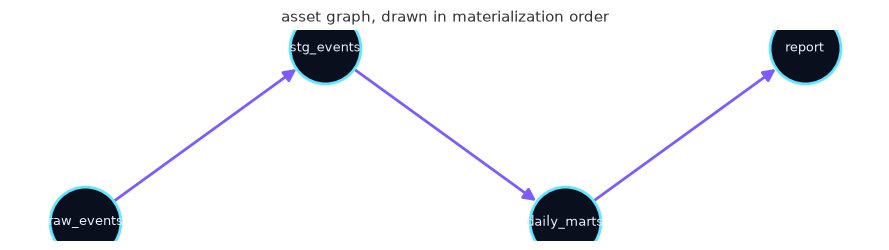

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
for n, a in g.assets.items():
    G.add_node(n)
    for d in a.deps:
        G.add_edge(d, n)

layer = {n: i for i, n in enumerate(order)}
pos = {n: (layer[n], -0.0) for n in G.nodes}
# spread nodes vertically a touch so labels do not collide
for i, n in enumerate(order):
    pos[n] = (i, (i % 2) * 0.4 - 0.2)

fig, ax = plt.subplots(figsize=(9, 2.6))
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#7c5cff", width=2,
                       arrowsize=18, node_size=2600)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#0a0f1e",
                       edgecolors="#62e6ff", linewidths=2, node_size=2600)
nx.draw_networkx_labels(G, pos, ax=ax, font_color="#e9edfb", font_size=9)
ax.set_title("asset graph, drawn in materialization order", color="#333", fontsize=11)
ax.axis("off")
plt.tight_layout()
plt.show()

That is orchestration in one notebook: a graph, a safe order, and a run. Everything from here adds the properties a real scheduler needs. Next: partitions and backfills, so a rerun does not redo work that is already done.